---
## 0. Import Library

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Library berhasil diimpor.')

Library berhasil diimpor.


---
## 1. Data Understanding

### 1.1 Load Dataset

In [33]:
# Tambahkan baris mounting jika belum dilakukan di sel sebelumnya
from google.colab import drive
drive.mount('/content/drive')

# Gunakan path lengkap ke folder DataSet PSD
df = pd.read_csv('/content/drive/MyDrive/DataSet PSD/paddy_productivity_scenario.csv')
dd = pd.read_csv('/content/drive/MyDrive/DataSet PSD/data_dictionary_paddy_productivity.csv')

print('Shape dataset:', df.shape)
print('\nData Dictionary:')
display(dd)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape dataset: (360, 15)

Data Dictionary:


,variable,description,type
0,farm_id,Kode unik lahan/petani,ID
1,region,Wilayah/agroekosistem lahan,Categorical
2,season,Musim tanam,Categorical
3,irrigation,Jenis sistem irigasi,Categorical
4,soil_quality,Kualitas tanah secara kategorikal,Categorical
5,rice_variety,Varietas padi yang digunakan,Categorical
6,rainfall_mm,Curah hujan rata-rata selama periode tanam (mm),Numerical
7,temperature_c,Suhu rata-rata selama periode tanam (derajat C...,Numerical
8,humidity_pct,Kelembaban rata-rata (%),Numerical
9,fertilizer_kg_ha,Jumlah pupuk yang digunakan per hektar (kg/ha),Numerical


### 1.2 Struktur Data

In [34]:
print('=== 5 Baris Pertama ===')
display(df.head())

print('\n=== Tipe Data ===')
print(df.dtypes)

print('\n=== Info Dataset ===')
df.info()

=== 5 Baris Pertama ===


,farm_id,region,season,irrigation,soil_quality,rice_variety,rainfall_mm,temperature_c,humidity_pct,fertilizer_kg_ha,pesticide_l_ha,land_area_ha,planting_density,yield_ton_ha,risk_category
0,FARM_225,Dataran Rendah,Musim Kemarau,Teknis,Sedang,Varietas C,123.65,26.24,61.71,90.91,0.85,1.77,24.70,7.52,Risiko Rendah
1,FARM_043,Dataran Rendah,Musim Hujan,Teknis,Tinggi,Varietas B,179.52,27.05,80.64,61.03,2.61,1.72,26.28,7.67,Risiko Rendah
2,FARM_286,Dataran Rendah,Musim Kemarau,Semi Teknis,Rendah,Varietas A,118.41,25.24,68.18,NaN,2.54,0.88,26.21,5.83,Risiko Rendah
3,FARM_303,Dataran Menengah,Musim Kemarau,Tadah Hujan,Tinggi,Varietas B,193.10,25.04,56.90,108.04,2.43,2.08,26.65,7.07,Risiko Rendah
4,FARM_057,Dataran Rendah,Musim Hujan,Teknis,Tinggi,Varietas B,314.36,26.12,83.94,107.33,1.71,1.08,16.56,6.03,Risiko Rendah



=== Tipe Data ===
farm_id              object
region               object
season               object
irrigation           object
soil_quality         object
rice_variety         object
rainfall_mm         float64
temperature_c       float64
humidity_pct        float64
fertilizer_kg_ha    float64
pesticide_l_ha      float64
land_area_ha        float64
planting_density    float64
yield_ton_ha        float64
risk_category        object
dtype: object

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   farm_id           360 non-null    object 
 1   region            360 non-null    object 
 2   season            360 non-null    object 
 3   irrigation        360 non-null    object 
 4   soil_quality      355 non-null    object 
 5   rice_variety      360 non-null    object 
 6   rainfall_mm       352 non-null    float

### 1.3 Identifikasi Missing Values

Variabel dengan Missing Values:


,Jumlah Missing,Persentase (%)
soil_quality,5,1.39
rainfall_mm,8,2.22
temperature_c,6,1.67
fertilizer_kg_ha,7,1.94


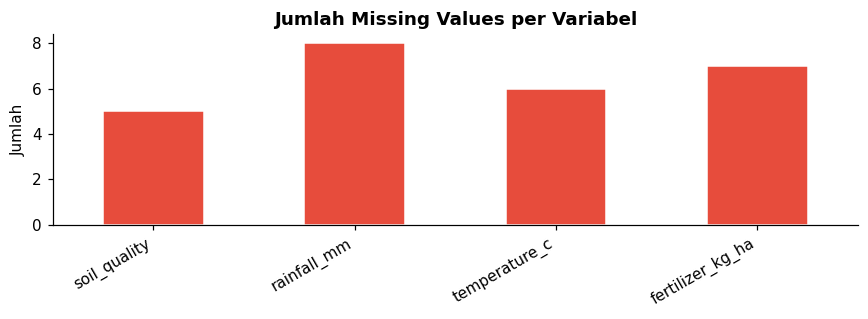

In [35]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0')

print('Variabel dengan Missing Values:')
display(missing_df)

# Visualisasi missing
fig, ax = plt.subplots(figsize=(8, 3))
missing_df['Jumlah Missing'].plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('Jumlah Missing Values per Variabel', fontweight='bold')
ax.set_ylabel('Jumlah')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 1.4 Statistik Deskriptif

In [36]:
print('=== Statistik Deskriptif Variabel Numerik ===')
display(df.describe().round(3))

print('\n=== Nilai Unik Variabel Kategorikal ===')
cat_cols = ['region', 'season', 'irrigation', 'soil_quality', 'rice_variety', 'risk_category']
for col in cat_cols:
    print(f'  {col}: {df[col].dropna().unique().tolist()}')

=== Statistik Deskriptif Variabel Numerik ===


,rainfall_mm,temperature_c,humidity_pct,fertilizer_kg_ha,pesticide_l_ha,land_area_ha,planting_density,yield_ton_ha
count,352.000,354.000,360.000,353.000,360.000,360.000,360.000,360.000
mean,178.952,27.171,77.332,113.518,2.208,1.437,23.492,6.711
std,71.860,1.918,9.749,28.393,0.840,0.776,3.968,1.621
min,30.000,22.440,50.060,35.000,0.200,0.300,12.000,0.910
25%,124.745,25.782,69.660,96.570,1.580,0.878,20.760,6.068
50%,166.290,27.195,78.800,112.740,2.215,1.240,23.765,6.990
75%,233.140,28.377,84.182,131.240,2.782,1.815,26.188,7.812
max,392.120,33.930,98.000,210.000,4.490,4.000,33.400,9.500



=== Nilai Unik Variabel Kategorikal ===
  region: ['Dataran Rendah', 'Dataran Menengah', 'Tadah Hujan', 'Dekat Sungai']
  season: ['Musim Kemarau', 'Musim Hujan']
  irrigation: ['Teknis', 'Semi Teknis', 'Tadah Hujan']
  soil_quality: ['Sedang', 'Tinggi', 'Rendah']
  rice_variety: ['Varietas C', 'Varietas B', 'Varietas A']
  risk_category: ['Risiko Rendah', 'Risiko Tinggi', 'Risiko Sedang']


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Histogram – Distribusi Variabel Numerik

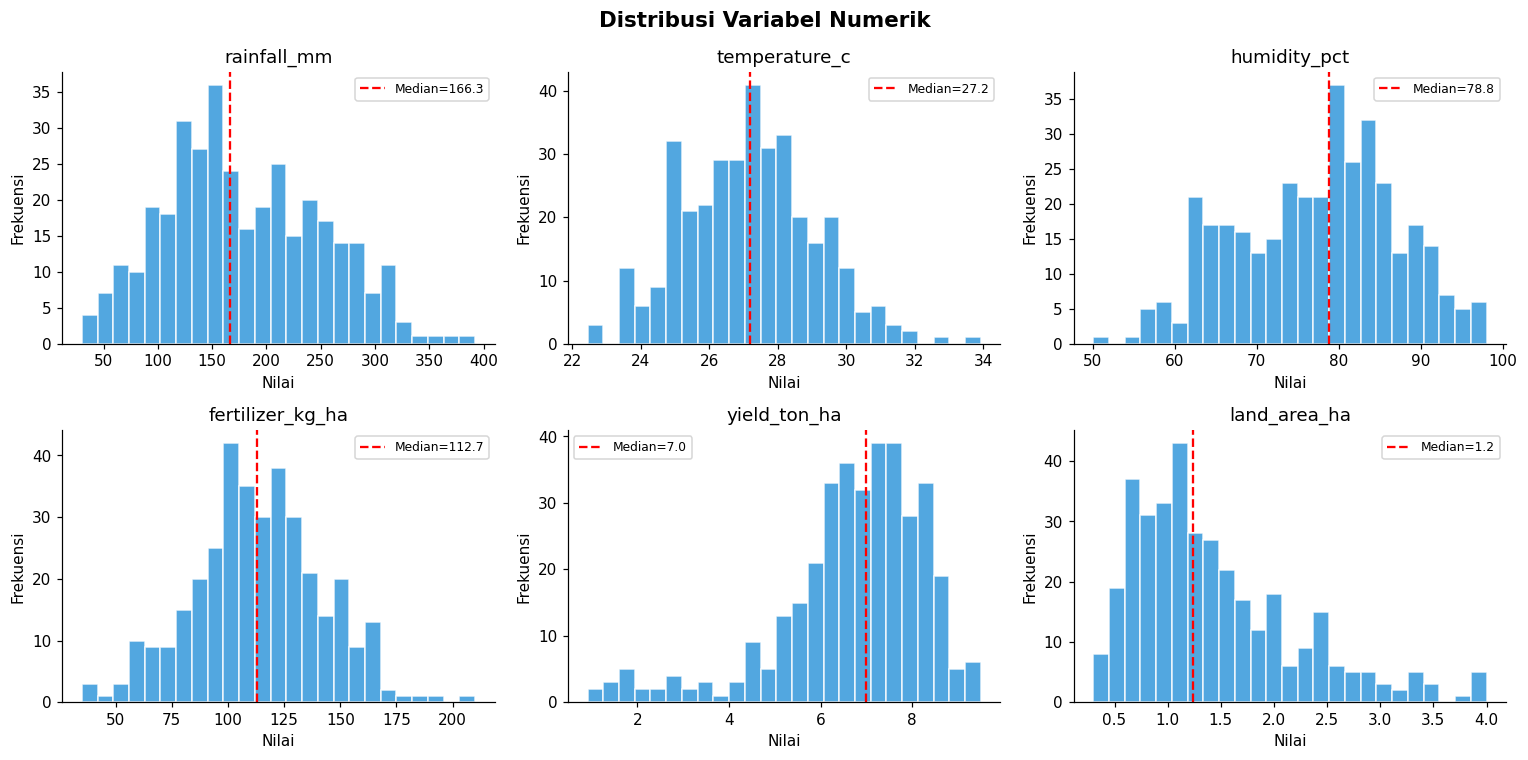

In [37]:
num_cols = ['rainfall_mm', 'temperature_c', 'humidity_pct',
            'fertilizer_kg_ha', 'yield_ton_ha', 'land_area_ha']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col].dropna(), bins=25, color='#3498db', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='red', linestyle='--', lw=1.5, label=f'Median={df[col].median():.1f}')
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretasi:**  
- `yield_ton_ha` terdistribusi relatif normal (mean ≈ 6.71 ton/ha, range 0.91–9.50), menunjukkan variasi signifikan antar lahan.  
- `rainfall_mm` right-skewed — sebagian lahan mendapat curah hujan sangat tinggi (>350 mm) yang berpotensi merusak panen.  
- `temperature_c` terkonsentrasi di 25–29°C sesuai kondisi tropis optimal untuk padi.

### 2.2 Scatter Plot – Relasi antar Variabel

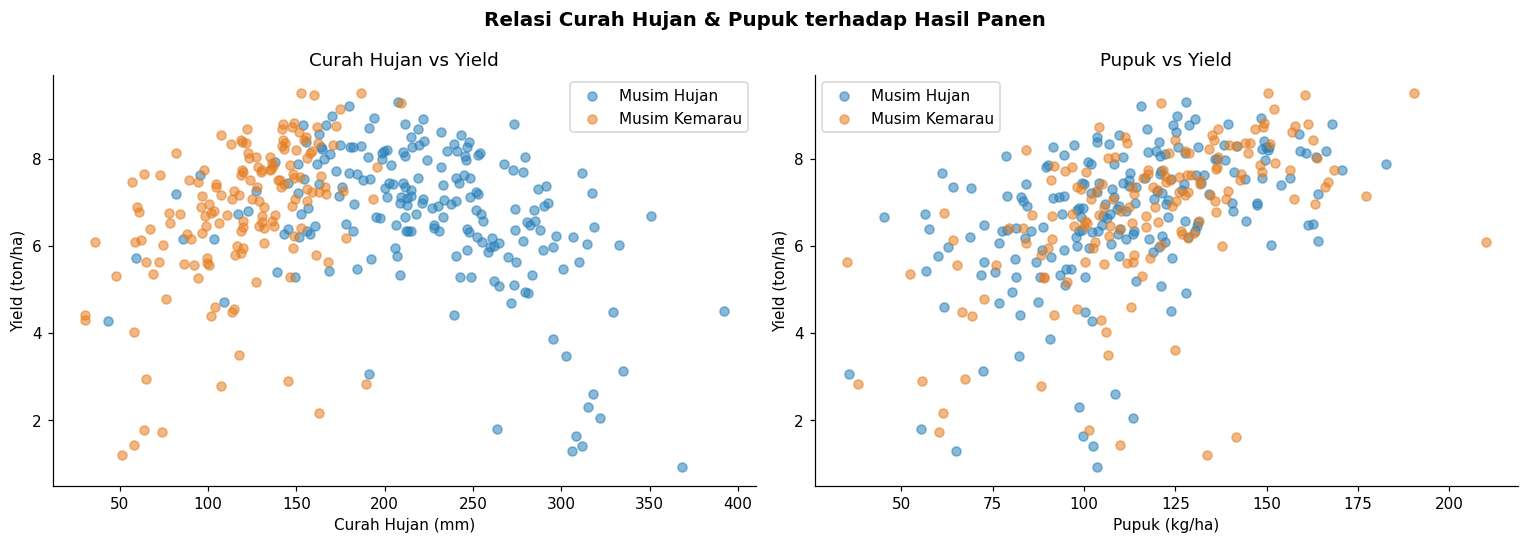

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relasi Curah Hujan & Pupuk terhadap Hasil Panen', fontsize=13, fontweight='bold')

colors_season = {'Musim Kemarau': '#e67e22', 'Musim Hujan': '#2980b9'}

for season, grp in df.groupby('season'):
    axes[0].scatter(grp['rainfall_mm'], grp['yield_ton_ha'],
                    alpha=0.55, label=season, color=colors_season[season], s=35)
axes[0].set_xlabel('Curah Hujan (mm)')
axes[0].set_ylabel('Yield (ton/ha)')
axes[0].set_title('Curah Hujan vs Yield')
axes[0].legend()

for season, grp in df.groupby('season'):
    axes[1].scatter(grp['fertilizer_kg_ha'], grp['yield_ton_ha'],
                    alpha=0.55, label=season, color=colors_season[season], s=35)
axes[1].set_xlabel('Pupuk (kg/ha)')
axes[1].set_ylabel('Yield (ton/ha)')
axes[1].set_title('Pupuk vs Yield')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretasi:**  
- Hubungan curah hujan–yield **tidak linear** — bersifat kuadratik. Yield optimal pada curah hujan moderat (100–250 mm), menurun tajam saat >350 mm akibat genangan.  
- Pupuk menunjukkan korelasi positif lemah dengan yield, namun terdapat titik jenuh — dosis berlebih tidak meningkatkan hasil.

### 2.3 Boxplot – Deteksi Outlier & Pengaruh Kategori

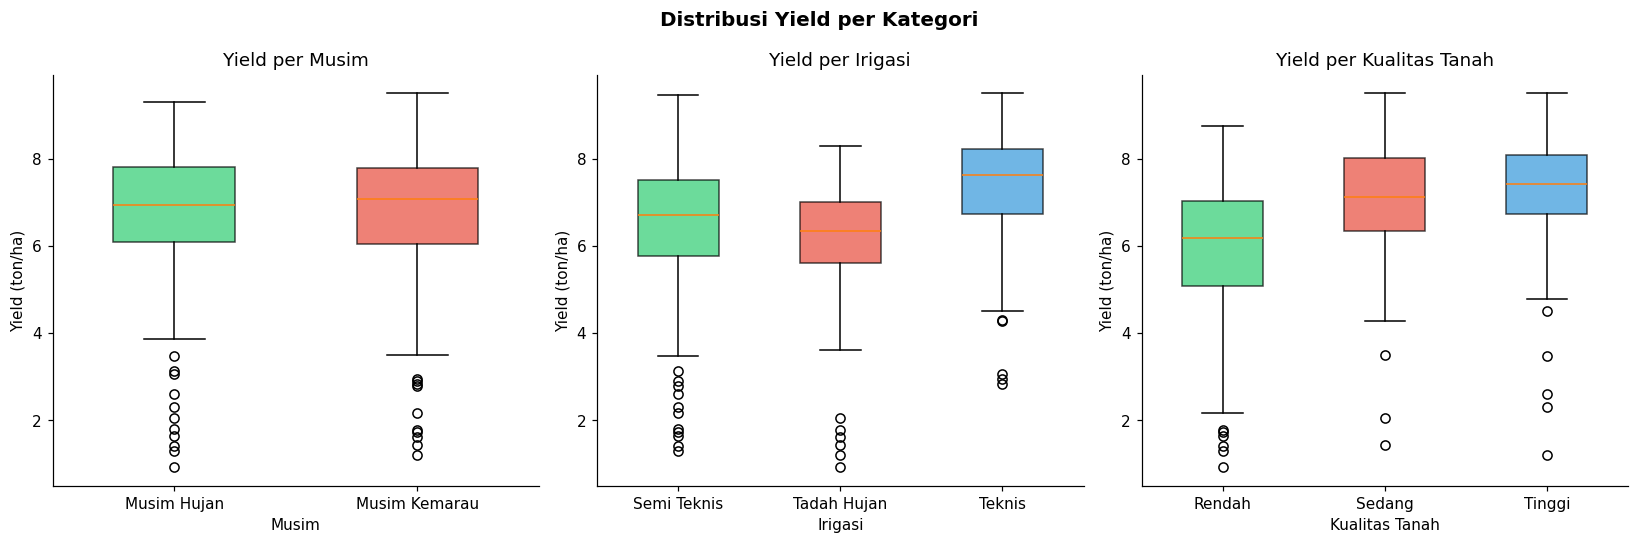

In [39]:
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Yield per Kategori', fontsize=13, fontweight='bold')

cats = [('season', 'Musim'), ('irrigation', 'Irigasi'), ('soil_quality', 'Kualitas Tanah')]

for ax, (col, label) in zip(axes, cats):
    order = sorted(df[col].dropna().unique())
    data = [df.loc[df[col] == c, 'yield_ton_ha'].dropna().values for c in order]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=order, widths=0.5)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('Yield (ton/ha)')
    ax.set_title(f'Yield per {label}')

plt.tight_layout()
plt.show()

**Interpretasi:**  
- **Irigasi Teknis** → yield tertinggi dan variasi terkecil (konsisten). **Tadah Hujan** → sangat sensitif terhadap cuaca (whisker panjang).  
- **Kualitas tanah Tinggi** → yield secara signifikan lebih tinggi.  
- Outlier yield sangat rendah (<2 ton/ha) **tidak dihapus** — merepresentasikan kasus gagal panen nyata yang penting untuk dipelajari model.

### 2.4 Analisis Kategorikal – Bar Chart

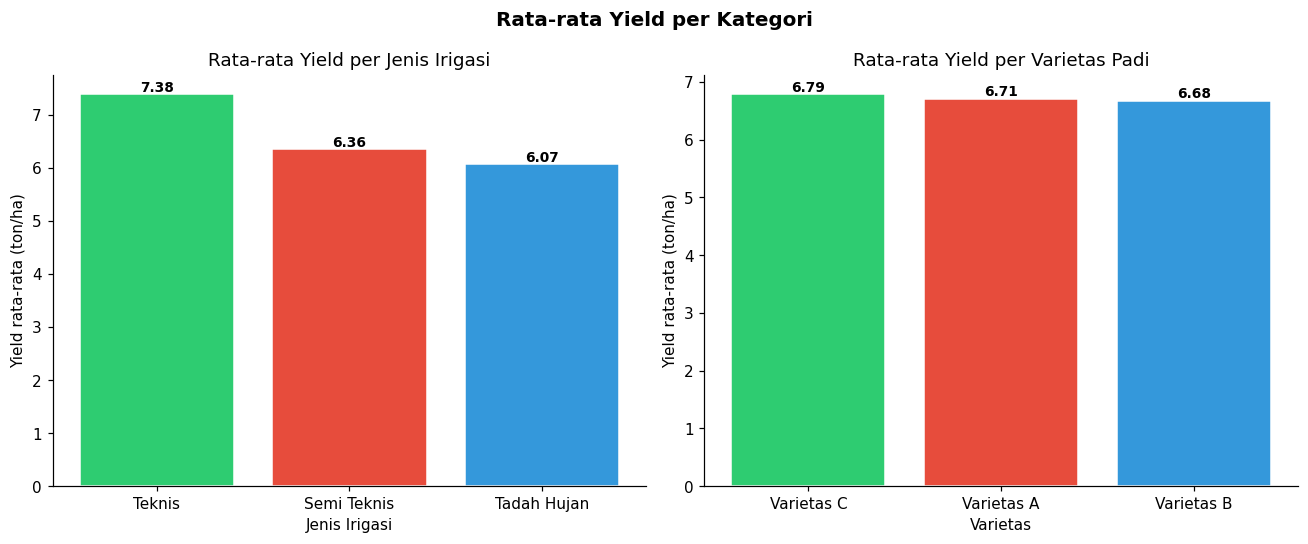

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Rata-rata Yield per Kategori', fontsize=13, fontweight='bold')

mean_irr = df.groupby('irrigation')['yield_ton_ha'].mean().sort_values(ascending=False)
axes[0].bar(mean_irr.index, mean_irr.values, color=COLORS[:3], edgecolor='white')
axes[0].set_title('Rata-rata Yield per Jenis Irigasi')
axes[0].set_ylabel('Yield rata-rata (ton/ha)')
axes[0].set_xlabel('Jenis Irigasi')
for i, v in enumerate(mean_irr.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

mean_var = df.groupby('rice_variety')['yield_ton_ha'].mean().sort_values(ascending=False)
axes[1].bar(mean_var.index, mean_var.values, color=COLORS[:3], edgecolor='white')
axes[1].set_title('Rata-rata Yield per Varietas Padi')
axes[1].set_ylabel('Yield rata-rata (ton/ha)')
axes[1].set_xlabel('Varietas')
for i, v in enumerate(mean_var.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretasi:**  
- Irigasi Teknis memberikan yield terbaik, diikuti Semi Teknis, dan Tadah Hujan terendah.  
- Varietas B dan C cenderung lebih unggul dari Varietas A, kemungkinan karena ketahanan terhadap hama dan kondisi iklim yang lebih baik.

### 2.5 Heatmap Korelasi

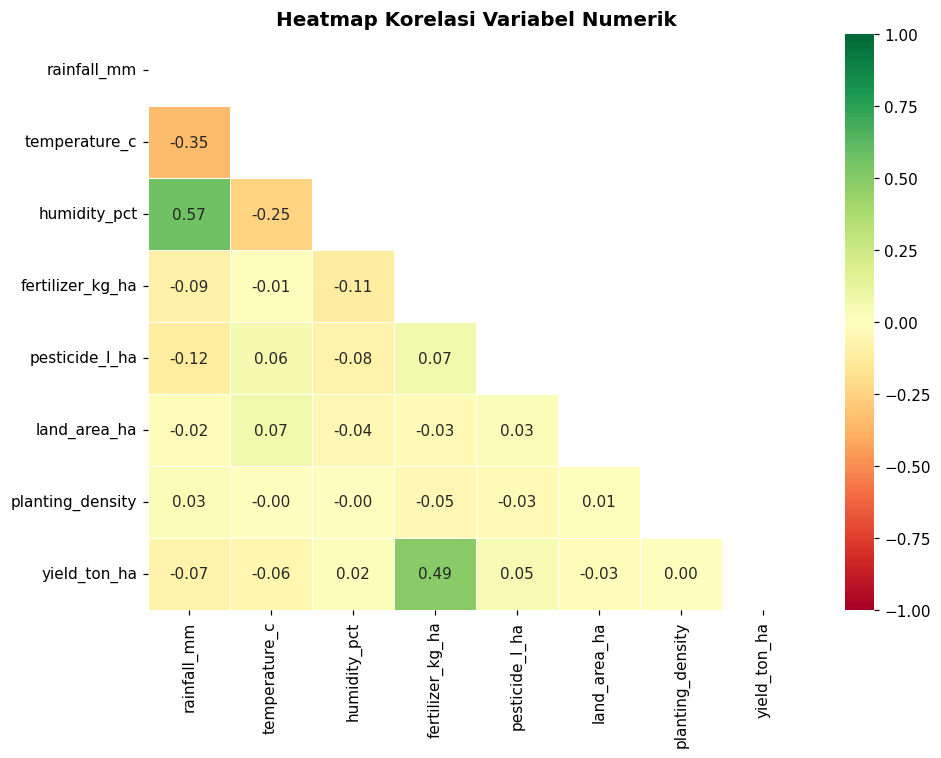

Korelasi tertinggi dengan yield_ton_ha:
fertilizer_kg_ha    0.485853
pesticide_l_ha      0.047649
humidity_pct        0.023358
planting_density    0.001959
land_area_ha       -0.027339
temperature_c      -0.060794
rainfall_mm        -0.074357
Name: yield_ton_ha, dtype: float64


In [41]:
corr_cols = ['rainfall_mm', 'temperature_c', 'humidity_pct',
             'fertilizer_kg_ha', 'pesticide_l_ha', 'land_area_ha',
             'planting_density', 'yield_ton_ha']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Korelasi tertinggi dengan yield_ton_ha:')
print(corr_matrix['yield_ton_ha'].sort_values(ascending=False).drop('yield_ton_ha'))

---
## 3. Data Cleaning

In [42]:
df_clean = df.copy()

# Imputasi numerik dengan median (robust terhadap skew & outlier)
for col in ['rainfall_mm', 'temperature_c', 'fertilizer_kg_ha']:
    median_val = df_clean[col].median()
    n_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'{col}: {n_missing} missing → diimputasi dengan median ({median_val:.2f})')

# Imputasi kategorikal dengan modus
mode_val = df_clean['soil_quality'].mode()[0]
n_missing = df_clean['soil_quality'].isnull().sum()
df_clean['soil_quality'] = df_clean['soil_quality'].fillna(mode_val)
print(f'soil_quality: {n_missing} missing → diimputasi dengan modus ("{mode_val}")')

print(f'\nVerifikasi – total missing setelah cleaning: {df_clean.isnull().sum().sum()}')

rainfall_mm: 8 missing → diimputasi dengan median (166.29)
temperature_c: 6 missing → diimputasi dengan median (27.20)
fertilizer_kg_ha: 7 missing → diimputasi dengan median (112.74)
soil_quality: 5 missing → diimputasi dengan modus ("Sedang")

Verifikasi – total missing setelah cleaning: 0


**Justifikasi metode imputasi:**
- **Median** untuk `rainfall_mm`, `temperature_c`, `fertilizer_kg_ha` → distribusi right-skewed, sehingga median lebih robust terhadap outlier dibanding mean.
- **Modus** untuk `soil_quality` (kategorikal) → mengisi dengan kategori yang paling sering muncul.

**Pertanyaan: Risiko penanganan missing value sembarangan?**  
Imputasi tidak tepat memperkenalkan bias — misal mengisi suhu dengan mean global padahal lahan berada di dataran tinggi yang lebih dingin. Ini membuat model belajar pola yang salah dan menghasilkan prediksi bias sistematis.

---
## 4. Feature Engineering

In [43]:
df_feat = df_clean.copy()

# Fitur 1: rainfall kuadrat – menangkap hubungan non-linear curah hujan vs yield
df_feat['rainfall_sq'] = df_feat['rainfall_mm'] ** 2

# Fitur 2: intensitas pemupukan per luas lahan
df_feat['fertilizer_per_area'] = df_feat['fertilizer_kg_ha'] / df_feat['land_area_ha']

# Fitur 3: interaksi suhu × kelembaban
df_feat['temp_humidity_interaction'] = df_feat['temperature_c'] * df_feat['humidity_pct']

print('3 fitur baru berhasil dibuat:')
print(df_feat[['rainfall_sq', 'fertilizer_per_area', 'temp_humidity_interaction']].describe().round(3))

3 fitur baru berhasil dibuat:
       rainfall_sq  fertilizer_per_area  temp_humidity_interaction
count      360.000              360.000                    360.000
mean     36961.509              105.243                   2096.637
std      27576.237               67.802                    269.021
min        900.000               17.036                   1366.968
25%      16106.148               55.390                   1935.362
50%      27652.364               91.540                   2119.062
75%      53871.777              131.427                   2262.478
max     153758.094              528.032                   2907.390


In [44]:
# Label Encoding untuk fitur kategorikal
df_enc = df_feat.copy()
le = LabelEncoder()
cat_cols = ['region', 'season', 'irrigation', 'soil_quality', 'rice_variety']

for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    print(f'{col}: encoded')

print('\nSample data setelah encoding:')
display(df_enc[cat_cols].head(3))

region: encoded
season: encoded
irrigation: encoded
soil_quality: encoded
rice_variety: encoded

Sample data setelah encoding:


,region,season,irrigation,soil_quality,rice_variety
0,1,1,2,1,2
1,1,0,2,2,1
2,1,1,0,0,0


**Penjelasan fitur baru:**

| Fitur | Formula | Alasan |
|-------|---------|--------|
| `rainfall_sq` | rainfall_mm² | EDA menunjukkan hubungan kuadratik; fitur ini membantu model linear menangkap pola kurvilinear |
| `fertilizer_per_area` | fertilizer_kg_ha / land_area_ha | Dosis pupuk absolut tidak bermakna tanpa konteks luas lahan; rasio ini merepresentasikan intensitas pemupukan |
| `temp_humidity_interaction` | temperature_c × humidity_pct | Interaksi suhu-kelembaban mempengaruhi evapotranspirasi secara sinergis, tidak tertangkap oleh masing-masing variabel |

---
## 5. Supervised Learning

### 5.1 Persiapan Data

In [31]:
features = [
    'region', 'season', 'irrigation', 'soil_quality', 'rice_variety',
    'rainfall_mm', 'temperature_c', 'humidity_pct', 'fertilizer_kg_ha',
    'pesticide_l_ha', 'land_area_ha', 'planting_density',
    'rainfall_sq', 'fertilizer_per_area', 'temp_humidity_interaction'
]

X = df_enc[features].fillna(df_enc[features].median())
y = df_enc['yield_ton_ha']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} sampel')
print(f'Test set    : {X_test.shape[0]} sampel')

Training set: 288 sampel
Test set    : 72 sampel


### 5.2 Model 1 – Linear Regression

In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('=== Linear Regression ===')
print(f'MAE  : {mae_lr:.4f} ton/ha')
print(f'RMSE : {rmse_lr:.4f} ton/ha')

=== Linear Regression ===
MAE  : 0.6366 ton/ha
RMSE : 0.8500 ton/ha


### 5.3 Model 2 – Random Forest Regressor

In [46]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('=== Random Forest Regressor ===')
print(f'MAE  : {mae_rf:.4f} ton/ha')
print(f'RMSE : {rmse_rf:.4f} ton/ha')

=== Random Forest Regressor ===
MAE  : 0.6984 ton/ha
RMSE : 0.8872 ton/ha


### 5.4 Perbandingan Model

In [47]:
eval_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (ton/ha)': [mae_lr, mae_rf],
    'RMSE (ton/ha)': [rmse_lr, rmse_rf]
})
print('=== Perbandingan Evaluasi Model ===')
display(eval_df.round(4))

=== Perbandingan Evaluasi Model ===


,Model,MAE (ton/ha),RMSE (ton/ha)
0,Linear Regression,0.6366,0.8500
1,Random Forest,0.6984,0.8872


### 5.5 Visualisasi Actual vs Predicted

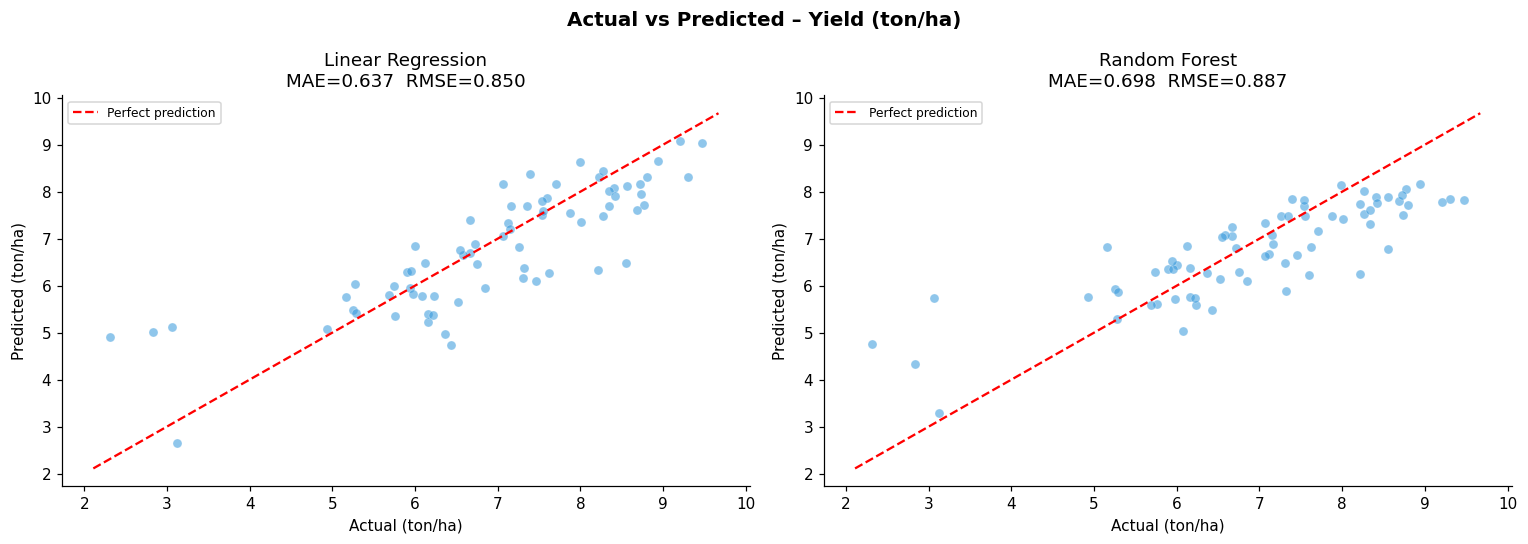

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actual vs Predicted – Yield (ton/ha)', fontsize=13, fontweight='bold')

for ax, (name, preds, mae, rmse) in zip(axes, [
    ('Linear Regression', y_pred_lr, mae_lr, rmse_lr),
    ('Random Forest', y_pred_rf, mae_rf, rmse_rf)
]):
    ax.scatter(y_test, preds, alpha=0.55, color='#3498db', s=35, edgecolors='white', lw=0.3)
    lims = [min(y_test.min(), preds.min()) - 0.2, max(y_test.max(), preds.max()) + 0.2]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual (ton/ha)')
    ax.set_ylabel('Predicted (ton/ha)')
    ax.set_title(f'{name}\nMAE={mae:.3f}  RMSE={rmse:.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.6 Feature Importance (Random Forest)

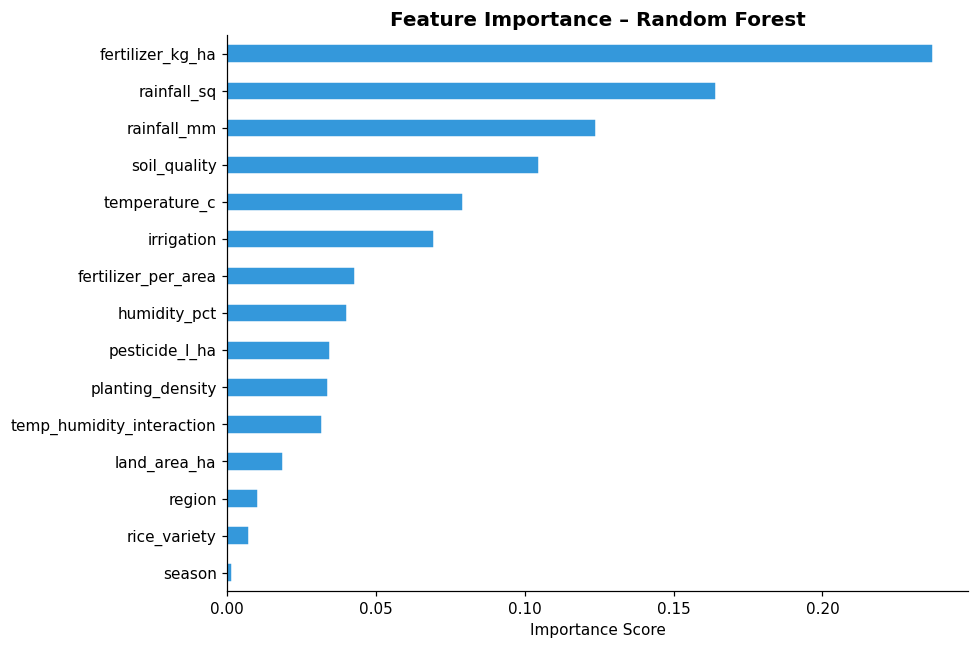

Top 5 fitur paling penting:
fertilizer_kg_ha    0.2371
rainfall_sq         0.1642
rainfall_mm         0.1239
soil_quality        0.1046
temperature_c       0.0793
dtype: float64


In [49]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Feature Importance – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 fitur paling penting:')
print(importances.sort_values(ascending=False).head(5).round(4))

---
## 6. Unsupervised Learning – KMeans Clustering

### 6.1 Persiapan & Elbow Method

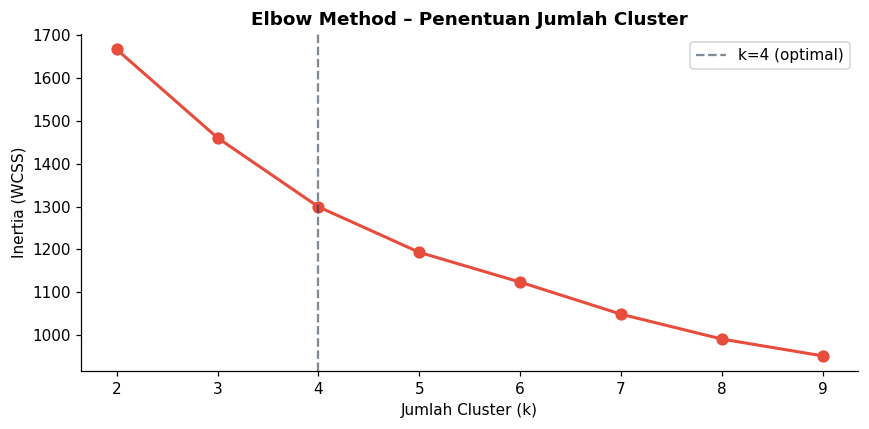

Berdasarkan Elbow Method, k=4 dipilih sebagai jumlah cluster optimal.


In [50]:
clust_features = ['rainfall_mm', 'temperature_c', 'humidity_pct',
                  'fertilizer_kg_ha', 'yield_ton_ha', 'planting_density']

X_clust = df_clean[clust_features].copy()
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_clust)

# Elbow method
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='#e74c3c', lw=2, markersize=7)
ax.axvline(4, ls='--', color='#2c3e50', alpha=0.6, label='k=4 (optimal)')
ax.set_xlabel('Jumlah Cluster (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method – Penentuan Jumlah Cluster', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Berdasarkan Elbow Method, k=4 dipilih sebagai jumlah cluster optimal.')

### 6.2 Training KMeans (k=4)

In [51]:
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km_final.fit_predict(X_sc)

X_clust = X_clust.copy()
X_clust['cluster'] = labels

print('Distribusi anggota per cluster:')
print(X_clust['cluster'].value_counts().sort_index())

Distribusi anggota per cluster:
cluster
0    123
1     82
2     97
3     58
Name: count, dtype: int64


### 6.3 Visualisasi Cluster

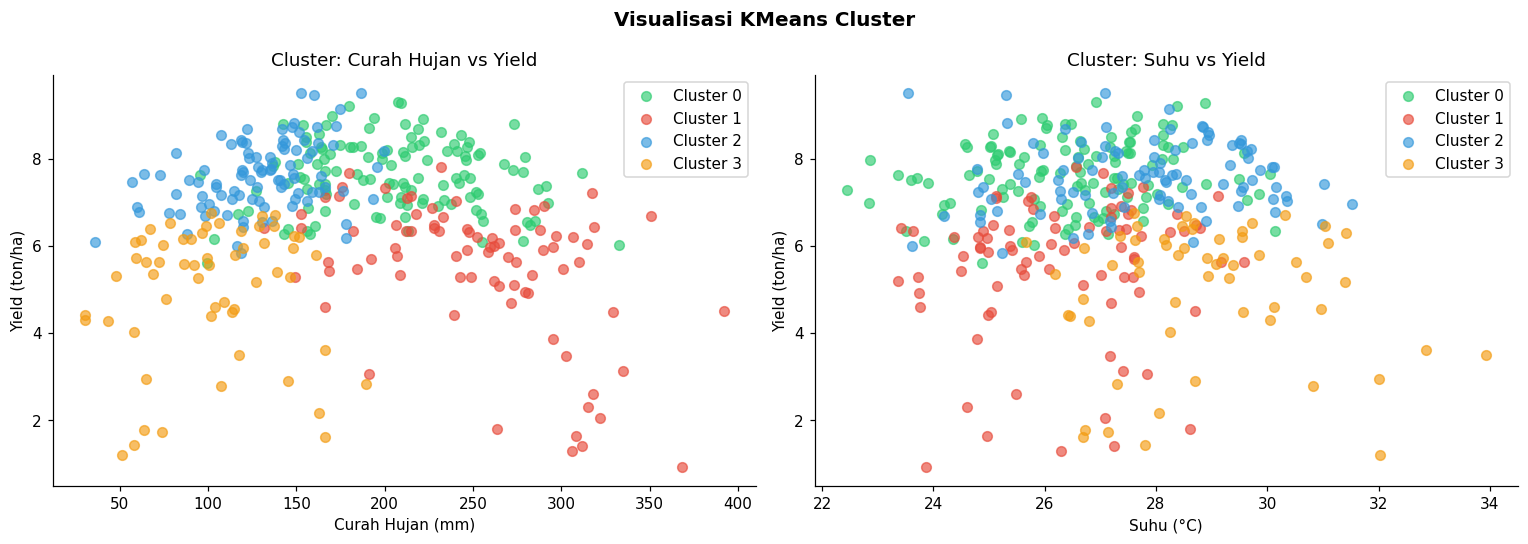

In [52]:
cmap = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Visualisasi KMeans Cluster', fontsize=13, fontweight='bold')

# Plot 1: Curah Hujan vs Yield
for c in range(best_k):
    mask = X_clust['cluster'] == c
    axes[0].scatter(X_clust.loc[mask, 'rainfall_mm'], X_clust.loc[mask, 'yield_ton_ha'],
                    label=f'Cluster {c}', color=cmap[c], alpha=0.65, s=40)
axes[0].set_xlabel('Curah Hujan (mm)')
axes[0].set_ylabel('Yield (ton/ha)')
axes[0].set_title('Cluster: Curah Hujan vs Yield')
axes[0].legend()

# Plot 2: Suhu vs Yield
for c in range(best_k):
    mask = X_clust['cluster'] == c
    axes[1].scatter(X_clust.loc[mask, 'temperature_c'], X_clust.loc[mask, 'yield_ton_ha'],
                    label=f'Cluster {c}', color=cmap[c], alpha=0.65, s=40)
axes[1].set_xlabel('Suhu (°C)')
axes[1].set_ylabel('Yield (ton/ha)')
axes[1].set_title('Cluster: Suhu vs Yield')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.4 Profil & Interpretasi Cluster

In [53]:
cprofile = X_clust.groupby('cluster')[clust_features].mean().round(2)
print('=== Profil Rata-rata per Cluster ===')
display(cprofile)

=== Profil Rata-rata per Cluster ===


,rainfall_mm,temperature_c,humidity_pct,fertilizer_kg_ha,yield_ton_ha,planting_density
cluster,,,,,,
0,204.98,26.48,83.71,124.19,7.62,23.19
1,251.95,26.32,83.85,88.43,5.53,24.45
2,129.43,27.74,67.43,132.38,7.60,23.09
3,101.62,28.89,71.15,94.73,4.97,23.46


**Interpretasi Cluster:**

| Cluster | Karakteristik Utama | Interpretasi Agronomis |
|---------|--------------------|-----------------------|
| **0** | Curah hujan cukup (~205 mm), pupuk optimal (~124 kg/ha), kelembaban tinggi | **Lahan produktif** – kondisi ideal, yield tertinggi (~7.6 t/ha) |
| **1** | Curah hujan berlebih (~252 mm), pupuk rendah (~88 kg/ha) | **Risiko genangan** – produktivitas sedang (~5.5 t/ha), perlu drainase |
| **2** | Curah hujan rendah (~129 mm), suhu cukup (~28°C), pupuk tinggi (~132 kg/ha) | **Lahan kering produktif** – kemungkinan irigasi teknis dominan, yield ~7.6 t/ha |
| **3** | Curah hujan sangat rendah (~102 mm), suhu tinggi (~29°C) | **Risiko kekeringan** – yield terendah (~5.0 t/ha), perlu intervensi irigasi |

**Manfaat clustering untuk pengambilan keputusan:**  
Dinas pertanian dapat merancang program intervensi spesifik per cluster — bantuan irigasi untuk Cluster 3, sistem drainase untuk Cluster 1 — sehingga alokasi sumber daya lebih tepat sasaran.